Dataset shape: (569, 30)
Class distribution:
 diagnosis
1    357
0    212
Name: count, dtype: int64

Optimal hyperparameters found: {'C': 5, 'gamma': 0.01}
Best cross-validation ROC-AUC: 0.9955

----- SVM (RBF Kernel) Performance on Test Set -----
Accuracy  : 0.9825
Precision : 0.9730
Recall    : 1.0000
F1 Score  : 0.9863
ROC-AUC   : 1.0000

Confusion Matrix:
 [[40  2]
 [ 0 72]]

Detailed Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.98        42
           1       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



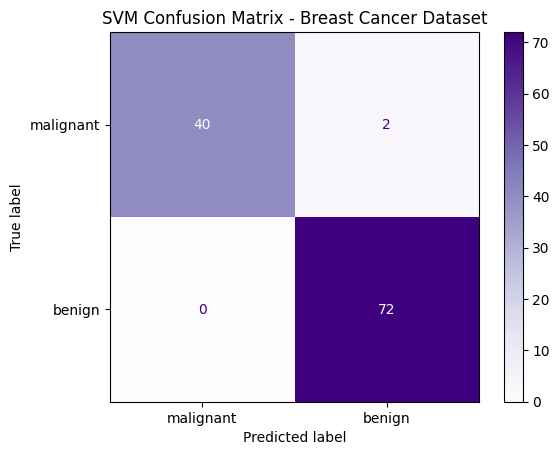

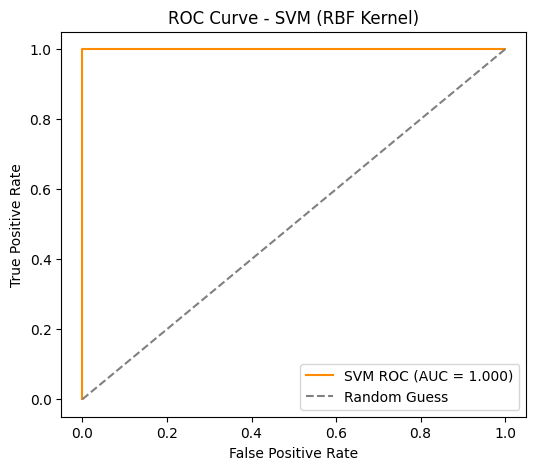

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

cancer_data = load_breast_cancer()
features_df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
target_series = pd.Series(cancer_data.target, name="diagnosis")

print("Dataset shape:", features_df.shape)
print("Class distribution:\n", target_series.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    features_df, target_series, test_size=0.2, random_state=21, stratify=target_series
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

base_model = SVC(kernel='rbf', probability=True, random_state=21)

tuning_grid = {
    "C": [0.5, 1, 5, 10, 50],
    "gamma": ["scale", "auto", 0.01, 0.001]
}

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=tuning_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)
print("\nOptimal hyperparameters found:", grid_search.best_params_)
print("Best cross-validation ROC-AUC:", round(grid_search.best_score_, 4))

final_model = grid_search.best_estimator_
final_model.fit(X_train_scaled, y_train)

y_hat = final_model.predict(X_test_scaled)
y_prob_pos = final_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_hat)
test_precision = precision_score(y_test, y_hat, zero_division=0)
test_recall = recall_score(y_test, y_hat)
test_f1 = f1_score(y_test, y_hat)
test_auc = roc_auc_score(y_test, y_prob_pos)
conf_mat = confusion_matrix(y_test, y_hat)

print("\n----- SVM (RBF Kernel) Performance on Test Set -----")
print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {test_precision:.4f}")
print(f"Recall    : {test_recall:.4f}")
print(f"F1 Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")
print("\nConfusion Matrix:\n", conf_mat)
print("\nDetailed Classification Report:\n", classification_report(y_test, y_hat, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=cancer_data.target_names)
disp.plot(cmap="Purples")
plt.title("SVM Confusion Matrix - Breast Cancer Dataset")
plt.show()

fpr_vals, tpr_vals, roc_thresh = roc_curve(y_test, y_prob_pos)
plt.figure(figsize=(6, 5))
plt.plot(fpr_vals, tpr_vals, color='darkorange', label=f"SVM ROC (AUC = {test_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (RBF Kernel)")
plt.legend(loc="lower right")
plt.show()